# 03 - Trade-off Response Model

Part B trains a response model for the N2412 trade-off table. The model maps design parameters to aerodynamic response:

```text
AoA, max camber, camber position, thickness -> CL, CD, CL/CD
```

This prepares the project for Part C, where the saved response model can be used as a fast objective function for design optimization.

## 1. Imports

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import KFold


## 2. Connect The Notebook To The Project

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "cfd_ml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from cfd_ml.paths import METRICS_DIR, TRADEOFF_MODEL_DIR
from cfd_ml.tradeoff import (
    TARGET_LABELS,
    TRADEOFF_FEATURES,
    TRADEOFF_TARGETS,
    build_tradeoff_models,
    evaluate_tradeoff_models,
    fit_tradeoff_model,
    load_tradeoff_modeling_data,
    predict_tradeoff_response,
    rank_tradeoff_models,
    split_tradeoff_features,
    summarize_tradeoff_scores,
)
from cfd_ml.tuning import (
    build_tradeoff_tuning_specs,
    encode_params_for_csv,
    params_to_json,
    tune_randomized_search_specs,
)

print(PROJECT_ROOT)


/Users/pun/Desktop/CFD-ML/CFD-Machine-learning


## 3. Load N2412 Trade-off Data

In [3]:
tradeoff_df = load_tradeoff_modeling_data()

print("Rows:", len(tradeoff_df))
print("Features:", TRADEOFF_FEATURES)
print("Targets:", TRADEOFF_TARGETS)
print("AoA range:", tradeoff_df["aoa"].min(), "to", tradeoff_df["aoa"].max())

tradeoff_df.head()

Rows: 480
Features: ['aoa', 'maxcamber', 'maxcamberposition', 'thickness']
Targets: ['cl', 'cd', 'cl_cd']
AoA range: -15 to 25


,id,design,aoa,maxcamber,maxcamberposition,thickness,cl,cd,cl_cd
0,1,Design 1,5,2.00,40,12.0,0.815590,0.017558,46.451719
1,2,Design 2,25,7.77,49,25.8,1.802180,0.250152,7.204340
2,3,Design 3,-11,6.05,16,8.1,-0.315530,0.135045,-2.336480
3,4,Design 4,-15,5.18,33,32.9,-0.635606,0.039020,-16.289236
4,5,Design 5,0,9.50,65,22.3,1.047800,0.035562,29.464117


## 4. Define The ML Problem

In [4]:
X, y = split_tradeoff_features(tradeoff_df)

X.head()

,aoa,maxcamber,maxcamberposition,thickness
0,5,2.00,40,12.0
1,25,7.77,49,25.8
2,-11,6.05,16,8.1
3,-15,5.18,33,32.9
4,0,9.50,65,22.3


In [5]:
y.describe()

,cl,cd,cl_cd
count,480.000000,480.000000,480.000000
mean,1.162044,0.072042,26.064067
std,0.742741,0.084987,17.163784
min,-1.163990,0.005715,-33.429812
25%,0.602206,0.018055,12.940457
50%,1.231180,0.044583,27.673820
75%,1.820742,0.092478,38.965487
max,2.360070,0.601579,60.479830


## 5. Compare Response Models

In [6]:
models = build_tradeoff_models()
scores_df, predictions_df = evaluate_tradeoff_models(models, X, y)
summary_df = summarize_tradeoff_scores(scores_df)

summary_df

,model,target,target_label,MAE_mean,RMSE_mean,R2_mean,RMSE_std
0,Gradient boosting,cd,CD,0.008019,0.015746,0.957949,0.001805
12,Random forest,cd,CD,0.009180,0.019285,0.943934,0.007431
9,Polynomial ridge d2,cd,CD,0.022590,0.032925,0.821333,0.005675
3,Linear regression,cd,CD,0.037241,0.058023,0.482709,0.012945
6,Mean baseline,cd,CD,0.057784,0.083581,-0.037685,0.018732
1,Gradient boosting,cl,CL,0.069481,0.102862,0.980501,0.022235
13,Random forest,cl,CL,0.098039,0.147676,0.959521,0.045967
10,Polynomial ridge d2,cl,CL,0.125360,0.172888,0.944602,0.022247
4,Linear regression,cl,CL,0.223536,0.294622,0.836365,0.037083
7,Mean baseline,cl,CL,0.624499,0.741357,-0.010513,0.059682


In [7]:
ranking_df = rank_tradeoff_models(summary_df, ranking_target="cl_cd")
best_model_name = ranking_df.iloc[0]["model"]

print("Best response model by CL/CD RMSE:", best_model_name)
ranking_df

Best response model by CL/CD RMSE: Random forest


,model,target,target_label,MAE_mean,RMSE_mean,R2_mean,RMSE_std
0,Random forest,cl_cd,CL/CD,2.824746,4.633192,0.924510,0.441353
1,Gradient boosting,cl_cd,CL/CD,3.762884,5.501697,0.893677,0.131479
2,Polynomial ridge d2,cl_cd,CL/CD,8.455049,11.203249,0.560829,0.457866
3,Linear regression,cl_cd,CL/CD,12.646053,16.323475,0.066729,1.348148
4,Mean baseline,cl_cd,CL/CD,14.277927,17.248226,-0.039830,0.775518


## 6. Tune Response Model Hyperparameters

The first ranking uses fixed/manual parameters. This section searches better hyperparameters with the same 5-fold validation setup, then creates a tuned ranking for the final response model.


In [8]:
tradeoff_tuning_specs = build_tradeoff_tuning_specs(random_state=42)
tuning_cv = KFold(n_splits=5, shuffle=True, random_state=42)

tuning_results_df, tuned_models = tune_randomized_search_specs(
    tradeoff_tuning_specs,
    X,
    y,
    cv=tuning_cv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    search_n_jobs=1,
)

tuning_results_df


Tuning Polynomial ridge tuned...


Tuning Random forest tuned...


Tuning Gradient boosting tuned...


,model,best_score,best_rmse,best_params,n_iter,cv_splits,scoring
2,Gradient boosting tuned,-1.439855,1.439855,"{'estimator__subsample': 0.9, 'estimator__n_es...",24,5,neg_root_mean_squared_error
1,Random forest tuned,-1.533087,1.533087,"{'n_estimators': 300, 'min_samples_split': 2, ...",24,5,neg_root_mean_squared_error
0,Polynomial ridge tuned,-3.576487,3.576487,"{'ridge__alpha': 0.1, 'polynomialfeatures__deg...",18,5,neg_root_mean_squared_error


In [9]:
tuned_scores_df, tuned_predictions_df = evaluate_tradeoff_models(tuned_models, X, y)
tuned_summary_df = summarize_tradeoff_scores(tuned_scores_df)
tuned_ranking_df = rank_tradeoff_models(tuned_summary_df, ranking_target="cl_cd")
best_tuned_model_name = tuned_ranking_df.iloc[0]["model"]

print("Best tuned response model by CL/CD RMSE:", best_tuned_model_name)
tuned_ranking_df


Best tuned response model by CL/CD RMSE: Gradient boosting tuned


,model,target,target_label,MAE_mean,RMSE_mean,R2_mean,RMSE_std
0,Gradient boosting tuned,cl_cd,CL/CD,2.653483,4.207752,0.938145,0.296929
1,Random forest tuned,cl_cd,CL/CD,2.727753,4.456286,0.930491,0.526859
2,Polynomial ridge tuned,cl_cd,CL/CD,6.756647,10.595536,0.603458,1.667298


## 7. Plot Tuned Model Comparison


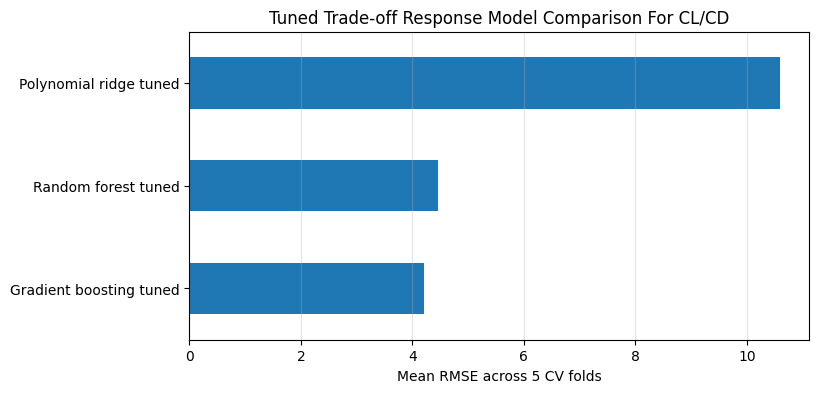

In [10]:
plot_df = tuned_ranking_df.set_index("model")

ax = plot_df["RMSE_mean"].sort_values(ascending=True).plot(
    kind="barh",
    figsize=(8, 4),
)
ax.set_xlabel("Mean RMSE across 5 CV folds")
ax.set_ylabel("")
ax.set_title("Tuned Trade-off Response Model Comparison For CL/CD")
ax.grid(True, axis="x", alpha=0.35)
plt.show()


## 8. Inspect Tuned Prediction Quality


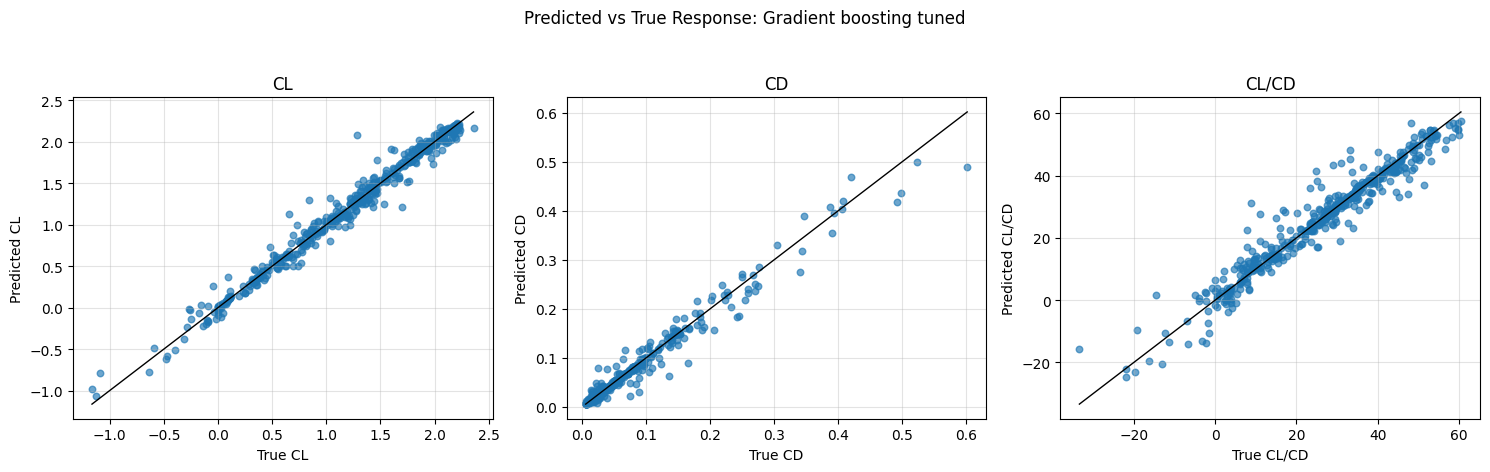

In [11]:
best_model_name = best_tuned_model_name
best_predictions = tuned_predictions_df[tuned_predictions_df["model"] == best_model_name].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, target in zip(axes, TRADEOFF_TARGETS):
    true_values = best_predictions[f"{target}_true"]
    pred_values = best_predictions[f"{target}_pred"]
    min_value = min(true_values.min(), pred_values.min())
    max_value = max(true_values.max(), pred_values.max())

    ax.scatter(true_values, pred_values, s=22, alpha=0.65)
    ax.plot([min_value, max_value], [min_value, max_value], color="black", linewidth=1)
    ax.set_xlabel(f"True {TARGET_LABELS[target]}")
    ax.set_ylabel(f"Predicted {TARGET_LABELS[target]}")
    ax.set_title(TARGET_LABELS[target])
    ax.grid(True, alpha=0.35)

fig.suptitle(f"Predicted vs True Response: {best_model_name}", y=1.04)
plt.tight_layout()
plt.show()


## 9. Train Final Tuned Response Model


In [12]:
final_model = fit_tradeoff_model(tuned_models[best_tuned_model_name], X, y)
best_tuning_row = tuning_results_df[
    tuning_results_df["model"] == best_tuned_model_name
].iloc[0]
best_params = json.loads(params_to_json(best_tuning_row["best_params"]))

METRICS_DIR.mkdir(parents=True, exist_ok=True)
TRADEOFF_MODEL_DIR.mkdir(parents=True, exist_ok=True)

summary_path = METRICS_DIR / "tradeoff_response_summary.csv"
scores_path = METRICS_DIR / "tradeoff_response_scores_by_fold.csv"
predictions_path = METRICS_DIR / "tradeoff_response_predictions.csv"
ranking_path = METRICS_DIR / "tradeoff_response_ranking.csv"
tuning_path = METRICS_DIR / "tradeoff_tuning_results.csv"
tuned_summary_path = METRICS_DIR / "tradeoff_tuned_response_summary.csv"
tuned_scores_path = METRICS_DIR / "tradeoff_tuned_response_scores_by_fold.csv"
tuned_predictions_path = METRICS_DIR / "tradeoff_tuned_response_predictions.csv"
tuned_ranking_path = METRICS_DIR / "tradeoff_tuned_response_ranking.csv"
model_path = TRADEOFF_MODEL_DIR / "response_model.joblib"
metadata_path = TRADEOFF_MODEL_DIR / "response_model_metadata.json"

summary_df.to_csv(summary_path, index=False)
scores_df.to_csv(scores_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
ranking_df.to_csv(ranking_path, index=False)
encode_params_for_csv(tuning_results_df).to_csv(tuning_path, index=False)
tuned_summary_df.to_csv(tuned_summary_path, index=False)
tuned_scores_df.to_csv(tuned_scores_path, index=False)
tuned_predictions_df.to_csv(tuned_predictions_path, index=False)
tuned_ranking_df.to_csv(tuned_ranking_path, index=False)
joblib.dump(final_model, model_path)
metadata_path.write_text(
    json.dumps(
        {
            "model_source": "tuned",
            "best_model": best_tuned_model_name,
            "best_params": best_params,
            "ranking_target": "cl_cd",
            "ranking_target_label": TARGET_LABELS["cl_cd"],
            "features": TRADEOFF_FEATURES,
            "targets": TRADEOFF_TARGETS,
            "training_rows": len(tradeoff_df),
            "cv_splits": 5,
            "random_state": 42,
            "tuning_method": "RandomizedSearchCV",
            "tuning_scoring": "neg_root_mean_squared_error",
        },
        indent=2,
    )
    + "\n"
)

print(summary_path)
print(scores_path)
print(predictions_path)
print(ranking_path)
print(tuning_path)
print(tuned_summary_path)
print(tuned_scores_path)
print(tuned_predictions_path)
print(tuned_ranking_path)
print(model_path)
print(metadata_path)


/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/tradeoff_response_summary.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/tradeoff_response_scores_by_fold.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/tradeoff_response_predictions.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/tradeoff_response_ranking.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/tradeoff_tuning_results.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/tradeoff_tuned_response_summary.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/tradeoff_tuned_response_scores_by_fold.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/tradeoff_tuned_response_predictions.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/tradeoff_tuned_response_ranking.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/models/tradeoff/response_model.joblib
/Users/pun/Desktop/CFD-ML/CFD-Mach

## 10. Try A Design Prediction


In [13]:
sample_design = {
    "aoa": 5,
    "maxcamber": 2.0,
    "maxcamberposition": 40,
    "thickness": 12.0,
}

predict_tradeoff_response(final_model, sample_design)

,aoa,maxcamber,maxcamberposition,thickness,cl_pred,cd_pred,cl_cd_pred
0,5,2.0,40,12.0,0.840511,0.017394,45.860811


## Conclusion

The best Part B response model is selected from the tuned ranking by held-out `CL/CD` RMSE. Baseline CSV files keep their original names, tuned CSV files use `tradeoff_tuned_*` names, and the final saved model metadata records the winning hyperparameters.
